# **Experiment 1: Build Your First Artificial Neural Network using MNIST**

**Course**

Advanced Neural Network Architectures (2306411T)



---


**Objective**


*   Understand Artificial Neural Networks (ANN)
*   Learn image classification using Deep Learning
*   Train an ANN using TensorFlow/Keras
*   Evaluate model performance
*   Study the effect of epochs and batch size






---


**Software**


*   Google Colab
*   Python 3
*   TensorFlow
*   Keras
*   Numpy
*   Matplotlib

---

**Dataset**

MNIST Handwritten Digits


*   70,000 grayscale images

*   Image Size: 28 * 28

*   Classes: 10(Digits 0 - 9)



---

**Theory**

Artificial Neural Networks (ANNs) are computational models inspired by biological neurons.

A neural network consists of


*   Input Layer
*   Hidden Layer(s)
*   Output Layer


In this experiment,

Input

↓

Flatten Layer

↓

Dense (128 Neurons)

↓

ReLU

↓

Dense (10 Neurons)

↓

Softmax

The model learns using the Adam Optimizer and Sparse Categorical Crossentropy Loss.

In [1]:
pip install tensorflow

In [2]:
# 1. Import Libraries

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix
import seaborn as sns

print("TensorFlow Version: ", tf.__version__)

TensorFlow Version:  2.20.0


In [3]:
# 2. Load Dataset

from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("x_train shape: ", x_train.shape)
print("y_train shape: ", y_train.shape)

x_train shape:  (60000, 28, 28)
y_train shape:  (60000,)


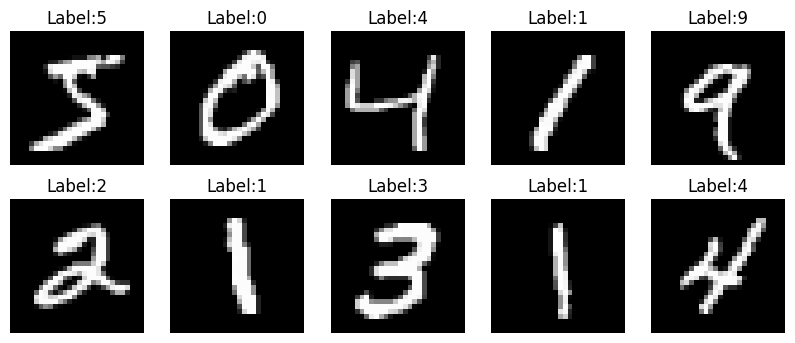

In [4]:
# 3. Display Sample Images

plt.figure(figsize=(10,4))

for i in range(10):

  plt.subplot(2, 5, i+1)
  plt.imshow(x_train[i], cmap='gray')
  plt.title("Label:"+str(y_train[i]))
  plt.axis('off')

plt.show()

In [5]:
# 4. Normalize Data

x_train = x_train / 255.0
x_test = x_test / 255.0

In [6]:
# 5. Build ANN Model

model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# 6. Compile Model

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [8]:
# 7. Train Model

from IPython.core import history

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9191 - loss: 0.2863 - val_accuracy: 0.9532 - val_loss: 0.1617
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9623 - loss: 0.1303 - val_accuracy: 0.9657 - val_loss: 0.1166
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9746 - loss: 0.0889 - val_accuracy: 0.9692 - val_loss: 0.1009
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9799 - loss: 0.0650 - val_accuracy: 0.9704 - val_loss: 0.0958
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9844 - loss: 0.0506 - val_accuracy: 0.9722 - val_loss: 0.0906
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9881 - loss: 0.0383 - val_accuracy: 0.9726 - val_loss: 0.0907
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9906 - loss: 0.0311 - val_accuracy: 0.9731 - val_loss: 0.0916
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9925 - loss: 0.0242 - 

In [9]:
# 8. Save Model

model.save("mnist_model.keras")
print("Model saved successfully!")

Model saved successfully!


In [10]:
# 9. Evaluate Model

loss, accuracy = model.evaluate(x_test, y_test)
print("Test Loss: ", loss)
print("Test Accuracy: ", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9773 - loss: 0.0778
Test Loss:  0.07784489542245865
Test Accuracy:  0.9772999882698059


In [11]:
# 10. Prediction

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


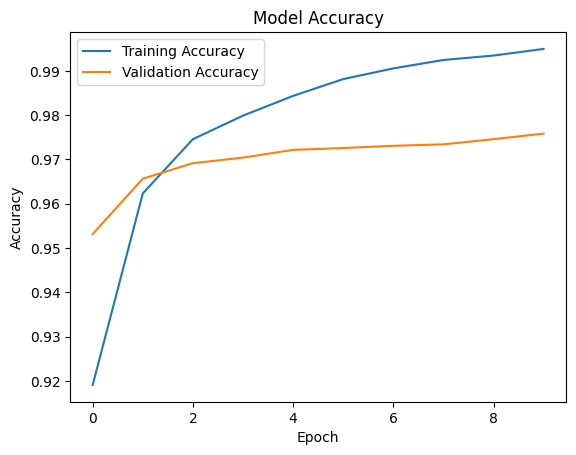

In [12]:
# 11. Accuracy Plot

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

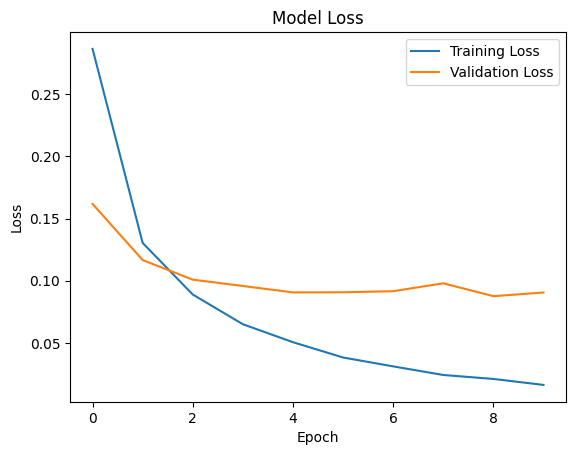

In [13]:
# 12. Loss Plot

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

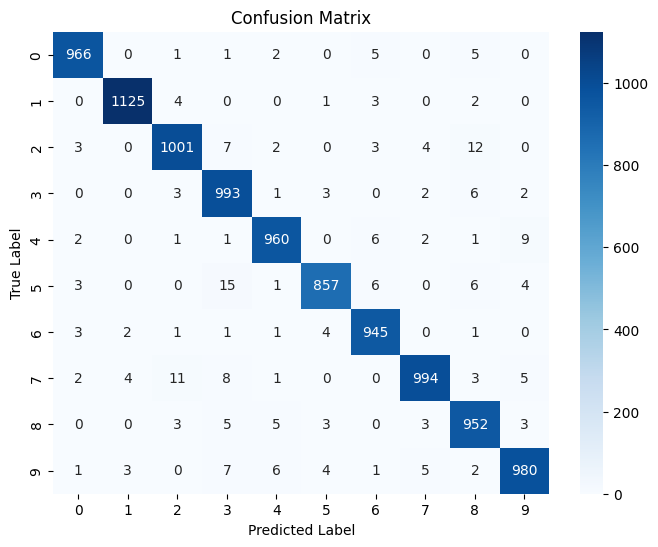

In [14]:
# 13. Confusion Matrix

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [15]:
# 14. Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.97      1032
           3       0.96      0.98      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.96      0.97       892
           6       0.98      0.99      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.96      0.98      0.97       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



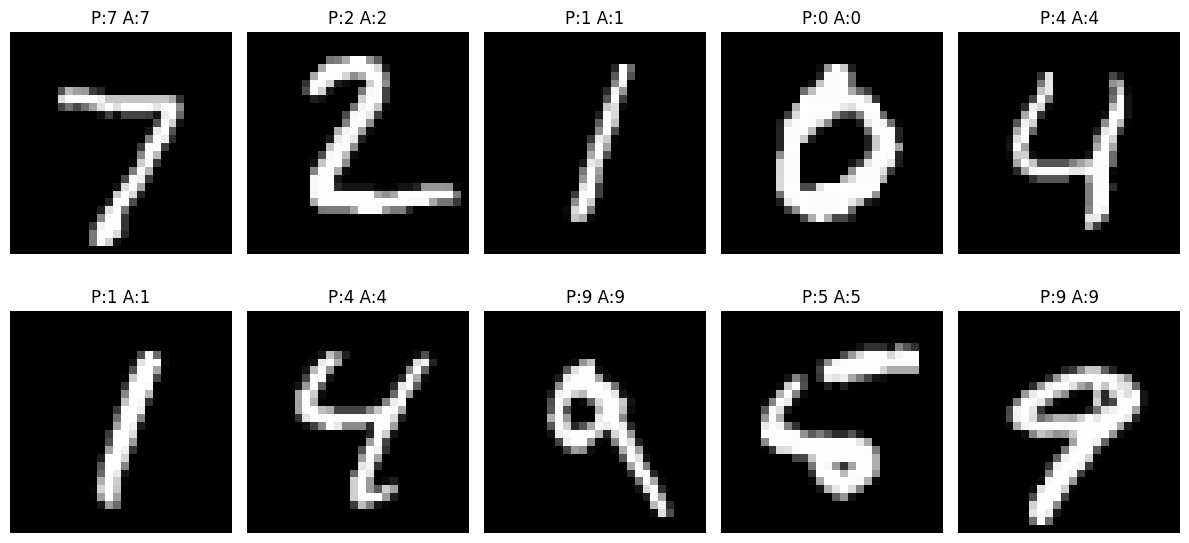

In [16]:
# 15. Display Sample Predictions

plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"P:{y_pred_classes[i]} A:{y_test[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Predicted: 7
Actual: 7
Confidence: 0.999957


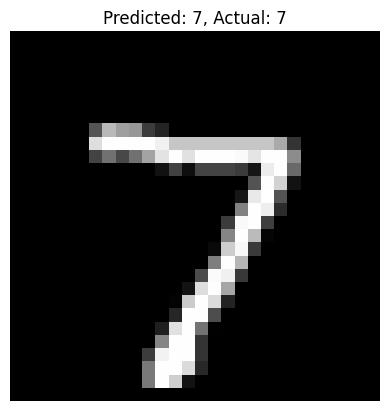

In [17]:
# 16. Display Prediction Confidence

prediction = model.predict(x_test)
y_pred_classes = np.argmax(prediction, axis=1)

predicted_class = y_pred_classes[0]
confidence = np.max(prediction[0])

print("Predicted:", predicted_class)
print("Actual:", y_test[0])
print("Confidence:", confidence)

plt.imshow(x_test[0], cmap='gray')
plt.title(f"Predicted: {predicted_class}, Actual: {y_test[0]}")
plt.axis('off')
plt.show()